# Prototyping Difference Gradient Analysis for MISalign 2.0

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as colors

In [8]:
# %matplotlib widget
%matplotlib inline

In [3]:
from misalign.model.project import MISProjectJSON
from misalign.model.relation import MISRelationRectangular
import misalign.alignment.difference_gradient as dga
import misalign.canvas.canvas_rectangular as cr

In [4]:
mis_filepath="../example/project_a/project_a-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)
print(mis_project)

A misalign project with:
Images:
    image_a01.jpg
    image_a02.jpg
    image_a03.jpg
    image_a04.jpg
    image_a05.jpg
    image_a06.jpg
    image_a07.jpg
    image_a08.jpg
    image_a09.jpg
    image_a10.jpg
Relations:
    ('image_a01.jpg', 'image_a02.jpg')
    ('image_a02.jpg', 'image_a03.jpg')
    ('image_a03.jpg', 'image_a04.jpg')
    ('image_a04.jpg', 'image_a05.jpg')
    ('image_a05.jpg', 'image_a06.jpg')
    ('image_a06.jpg', 'image_a07.jpg')
    ('image_a07.jpg', 'image_a08.jpg')
    ('image_a08.jpg', 'image_a09.jpg')
    ('image_a09.jpg', 'image_a10.jpg')
Calibration:
    pixel : 600
    length : 1
    length_unit : mm
Project Path:
    ..\example\project_a\project_a-relations-calibrated.mis.json


In [7]:
plt.close('all')

In [5]:
# 2 is fairly well overlapped
# 7 is neat for seeing how physical features effect plot.
# 8 is particularly bad initial alignment and good for visualizing
selected_relation=mis_project.get_relations()[8]
selected_dga_results=dga.difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        relation=selected_relation,
        strategy=dga.strategy_scaled_grid,
        metric=dga.metric_squared_mean,
        strategy_max_size=20,
        strategy_grid_scale=1,
        filter=dga.filter_rgb_gray
        )
print("Initial:",selected_dga_results["initial_offset"],"Optimized:",selected_dga_results["optimized_offset"])

Initial: (3, -722) Optimized: (4, -715)


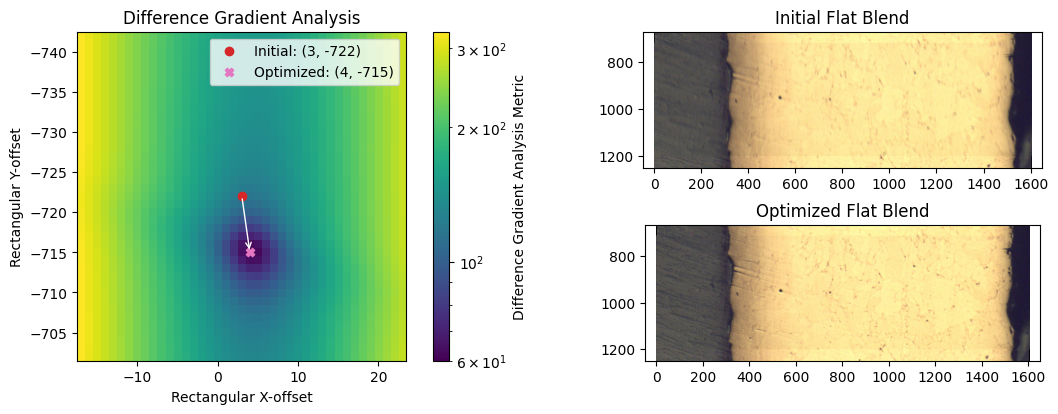

In [9]:
dga.plot_grid_difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        dga_grid_result=selected_dga_results,
    )
plt.show()

0 : ('image_a01.jpg', 'image_a02.jpg') (12, -1088) -> (9, -1087)


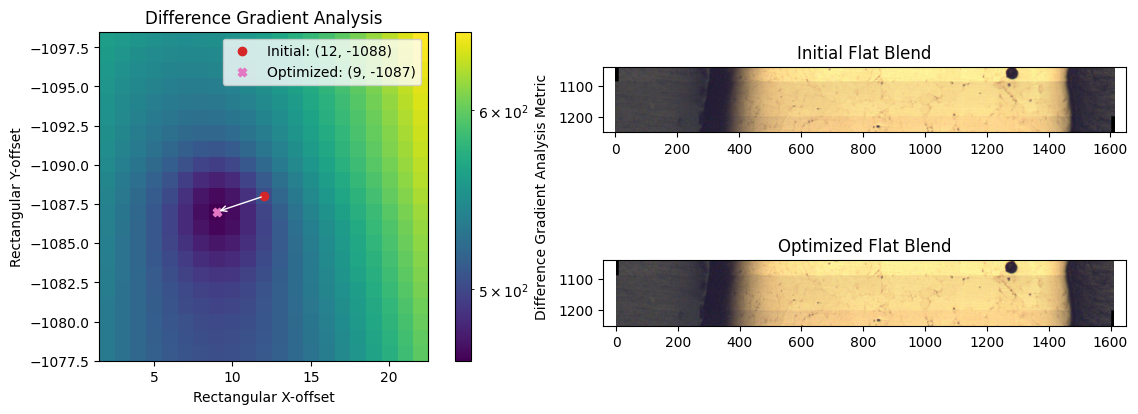

1 : ('image_a02.jpg', 'image_a03.jpg') (8, -1141) -> (8, -1146)


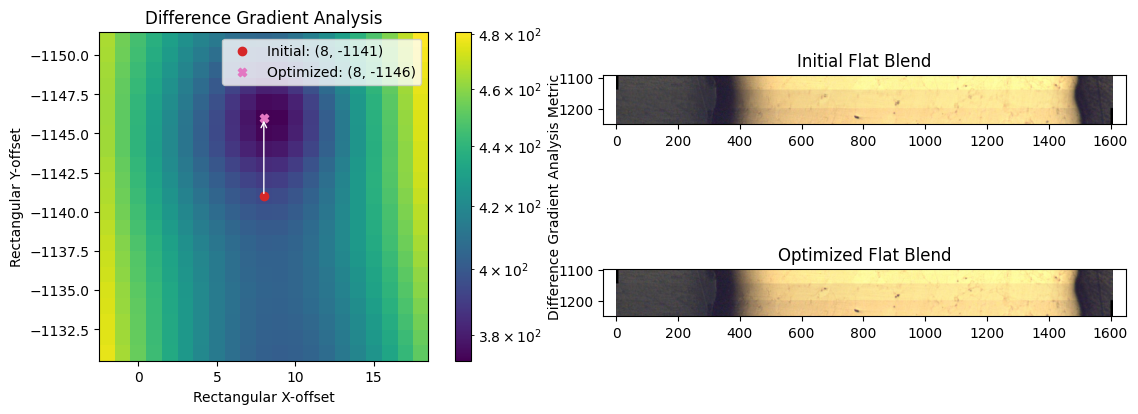

2 : ('image_a03.jpg', 'image_a04.jpg') (-129, -1058) -> (-124, -1060)


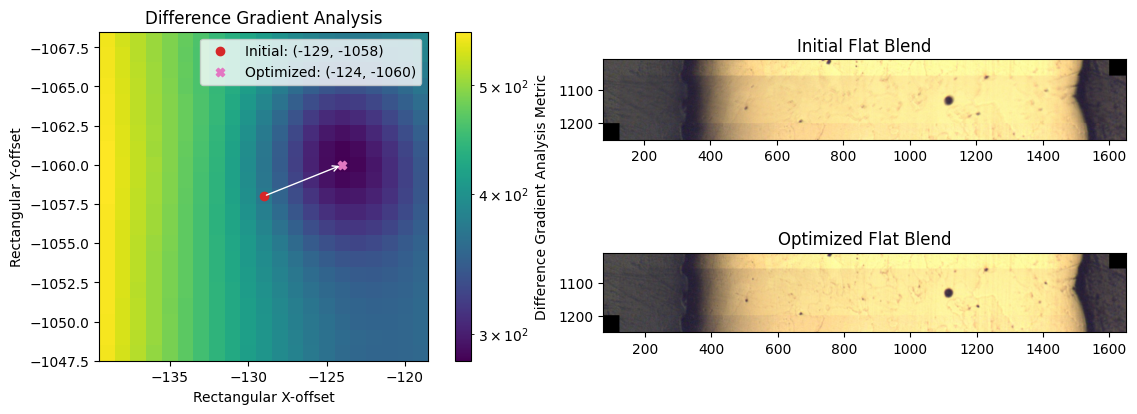

3 : ('image_a04.jpg', 'image_a05.jpg') (11, -943) -> (10, -942)


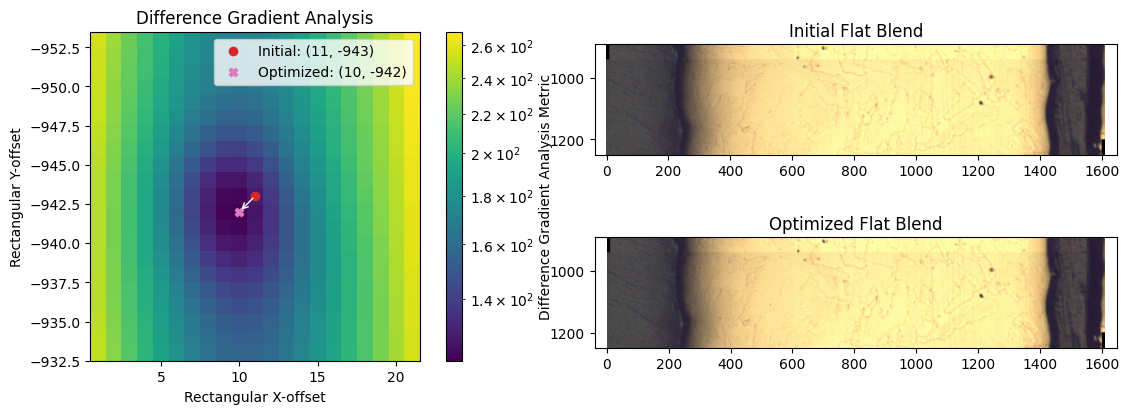

4 : ('image_a05.jpg', 'image_a06.jpg') (5, -860) -> (7, -857)


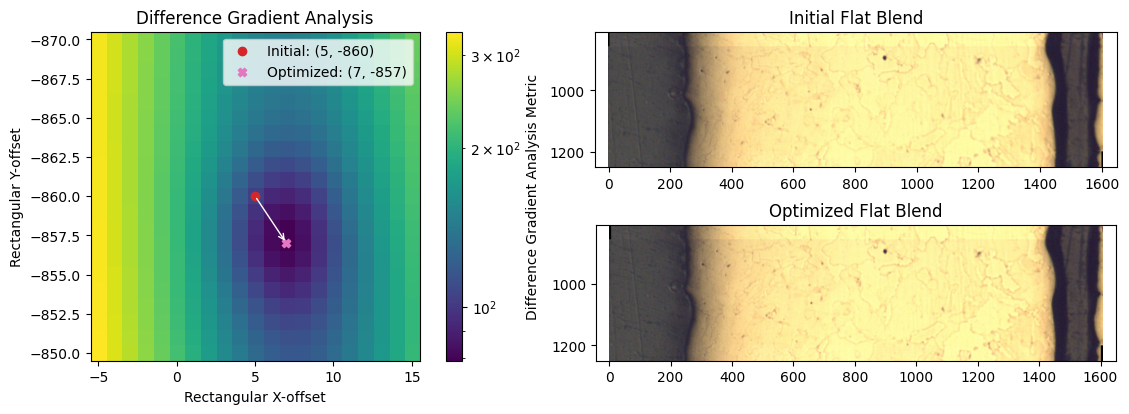

5 : ('image_a06.jpg', 'image_a07.jpg') (10, -990) -> (8, -989)


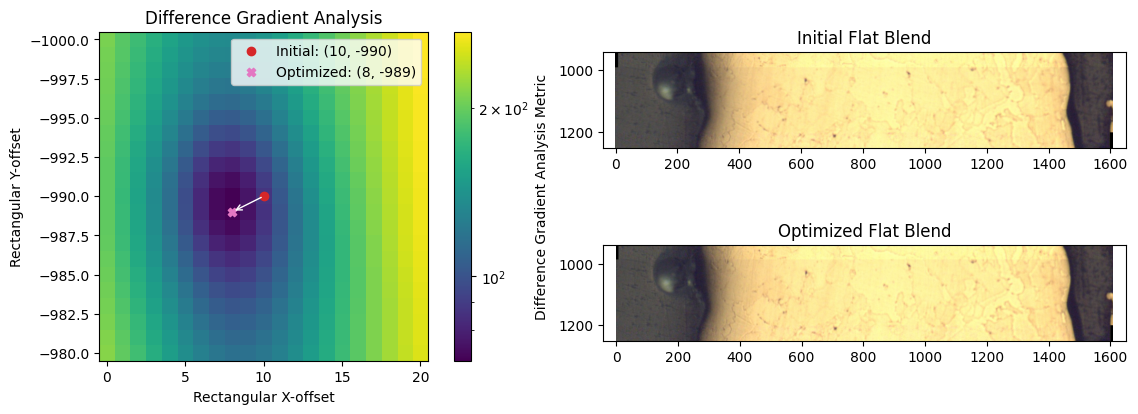

6 : ('image_a07.jpg', 'image_a08.jpg') (9, -1009) -> (8, -1008)


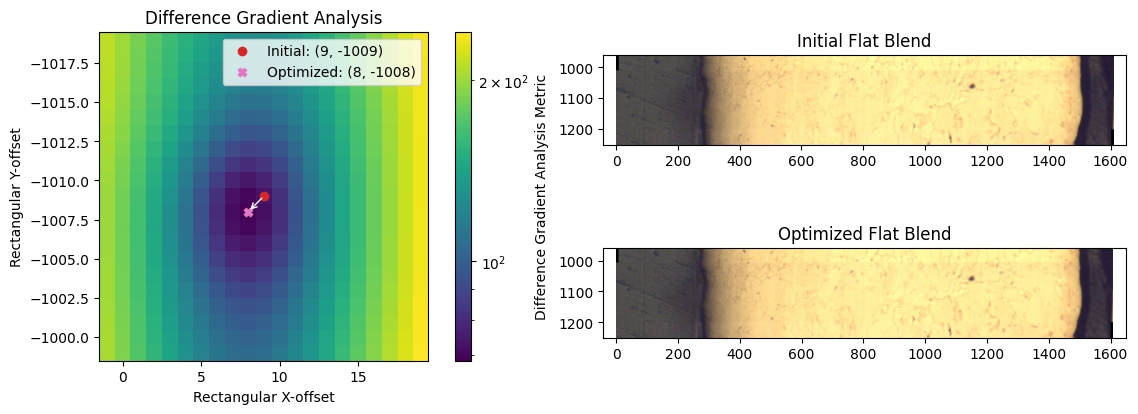

7 : ('image_a08.jpg', 'image_a09.jpg') (9, -939) -> (8, -938)


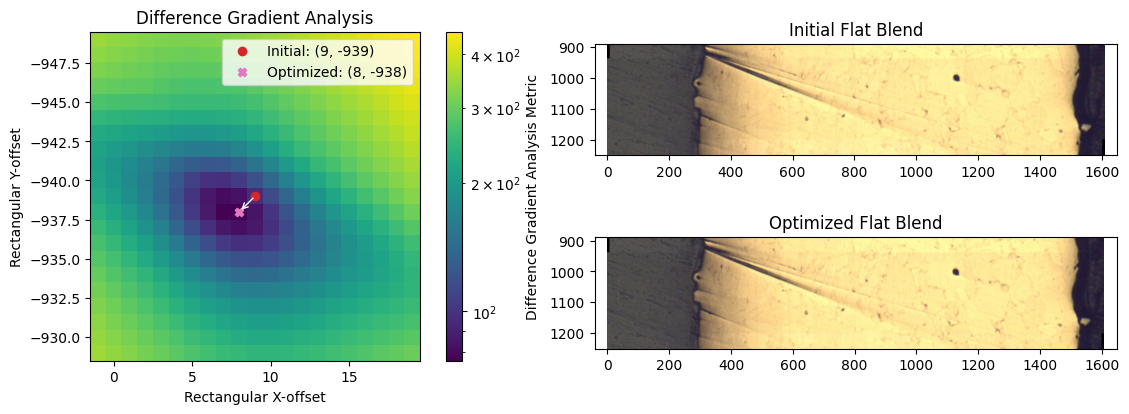

8 : ('image_a09.jpg', 'image_a10.jpg') (3, -722) -> (4, -715)


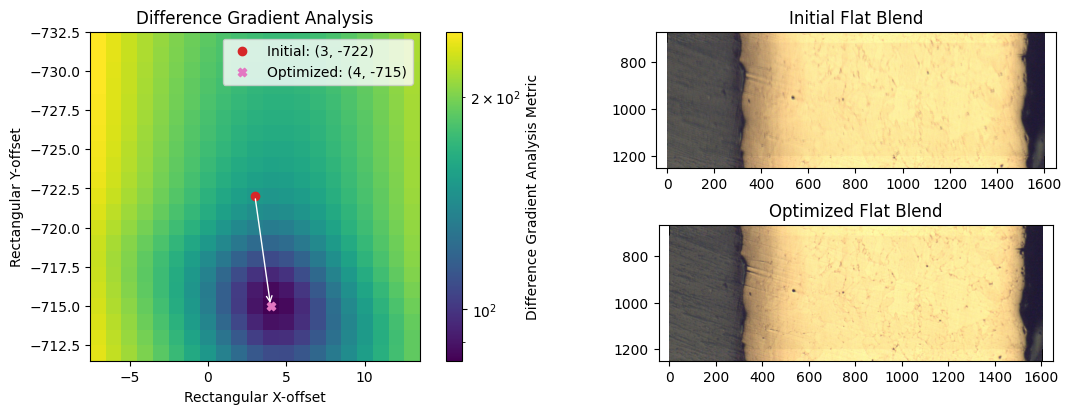

In [9]:
relation_index_results=dict()
for i,relation in enumerate(mis_project.get_relations()):
    dga_results=dga.difference_gradient_analysis(
            image_a=mis_project.get_image(relation.get_reference()[0]),
            image_b=mis_project.get_image(relation.get_reference()[1]),
            relation=relation,
            strategy=dga.strategy_full_grid,
            metric=dga.metric_squared_mean,
            strategy_max_size=10,
            )
    print(i,":",relation.get_reference(),relation.get_relation('r'),"->",dga_results["optimized_offset"])
    dga.plot_grid_difference_gradient_analysis(
        image_a=mis_project.get_image(relation.get_reference()[0]),
        image_b=mis_project.get_image(relation.get_reference()[1]),
        dga_grid_result=dga_results,
    )
    plt.show()
    

In [ ]:
# [mis_project.set_relation(i,relation) for i,relation in relation_index_results.items()]
# mis_filepath="../example/project_a/project_a-dga_relations-calibrated.mis.json"
# mis_project.save(mis_filepath)

# Comparing Performances

In [ ]:
# Using `mis_project.get_relations()[1]` which has an ideal offset of `(8, -1146)`
# We can check strategy_max_size=50 which gives 101x101=10201 offsets.
# Not including plotting the cell takes 7.3s to run.
# Using `mis_project.get_relations()[2]` which has an ideal offset of `(-124, -1060)`
# strategy_max_size=50 which gives 201x201=40401 > Not including plotting takes 16.9s to run.
    # 16.9s using np.int32 / 12.5s using np.int16
# strategy_max_size=100 which gives 201x201=40401 > Not including plotting takes 67.3s to run.
# In general: Higher overlap takes more time, strategy size has squared relationship with run time.

# Trying out filters:
    # with `dga.metric_squared_mean`
        # `mis_project.get_relations()[2]` > `strategy_max_size=50` > `filter=filter_rgb_gray` > 3.2s
        # `mis_project.get_relations()[2]` > `strategy_max_size=100` > no filter > 48.3s
        # `mis_project.get_relations()[2]` > `strategy_max_size=100` > `filter=filter_rgb_gray` > 15.4s
        # `mis_project.get_relations()[2]` > `strategy_max_size=100` > `filter=filter_rgb_gray_reduced` > 12.2s
            # return np.sqrt(np.mean(image,axis=-1)).astype(np.uint8) > Not worth the added complexity.
    # with `dga.metric_absolute_mean`
        # `mis_project.get_relations()[2]` > `strategy_max_size=100` > no filter > 50.9s
        # `mis_project.get_relations()[2]` > `strategy_max_size=100` > `filter=filter_rgb_gray` > 12.9s

# Note: time is fairly variable run-to-run
    # Should implement performance timing

In [11]:
import timeit
import pandas as pd
import seaborn as sns

In [11]:
# 2 is fairly well overlapped
# 8 is extremely well overlapped
performance_relation=mis_project.get_relations()[2]
performance_optimized_relation=(-124, -1060) # for [2]
performance_dga_results=dga.difference_gradient_analysis(
        image_a=mis_project.get_image(performance_relation.get_reference()[0]),
        image_b=mis_project.get_image(performance_relation.get_reference()[1]),
        relation=performance_relation,
        strategy=dga.strategy_scaled_grid,
        metric=dga.metric_squared_mean,
        strategy_max_size=20,
        strategy_grid_scale=1,
        filter=dga.filter_rgb_gray
        )
print("Initial:",performance_dga_results["initial_offset"],"Optimized:",performance_dga_results["optimized_offset"])
def performance_run(kwargs):
    performance_dga_results=dga.difference_gradient_analysis(
        image_a=mis_project.get_image(performance_relation.get_reference()[0]),
        image_b=mis_project.get_image(performance_relation.get_reference()[1]),
        relation=performance_relation,
        **kwargs
        )
    assert performance_dga_results["optimized_offset"]==performance_optimized_relation # this makes sure that the same result is found
def get_run_description(kwargs)->dict:
    return {key:(value.__name__ if hasattr(value,"__name__") else value) for key,value in kwargs.items()}
performance_repeats=5
performance_repeats_long=1
performance_results=list()

Initial: (-129, -1058) Optimized: (-124, -1060)


In [12]:
kwargs=dict(
    strategy=dga.strategy_full_grid,
    metric=dga.metric_squared_mean,
    strategy_max_size=20,
    filter=dga.filter_simple
    )
run_result=get_run_description(kwargs)
run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
print(run_result)
performance_results.append(run_result)

kwargs=dict(
    strategy=dga.strategy_full_grid,
    metric=dga.metric_squared_mean,
    strategy_max_size=20,
    filter=dga.filter_rgb_gray
    )
run_result=get_run_description(kwargs)
run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
print(run_result)
performance_results.append(run_result)

kwargs=dict(
    strategy=dga.strategy_full_grid,
    metric=dga.metric_squared_mean,
    strategy_max_size=50,
    filter=dga.filter_rgb_gray
    )
run_result=get_run_description(kwargs)
run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
print(run_result)
performance_results.append(run_result)

kwargs=dict(
    strategy=dga.strategy_full_grid,
    metric=dga.metric_squared_mean,
    strategy_max_size=100,
    filter=dga.filter_rgb_gray
    )
run_result=get_run_description(kwargs)
run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats_long)/performance_repeats_long
print(run_result)
performance_results.append(run_result)

{'strategy': 'strategy_full_grid', 'metric': 'metric_squared_mean', 'strategy_max_size': 20, 'filter': 'filter_simple', 'average_time': 2.1364102000021377}
{'strategy': 'strategy_full_grid', 'metric': 'metric_squared_mean', 'strategy_max_size': 20, 'filter': 'filter_rgb_gray', 'average_time': 0.5746257999999216}
{'strategy': 'strategy_full_grid', 'metric': 'metric_squared_mean', 'strategy_max_size': 50, 'filter': 'filter_rgb_gray', 'average_time': 3.239154920002329}
{'strategy': 'strategy_full_grid', 'metric': 'metric_squared_mean', 'strategy_max_size': 100, 'filter': 'filter_rgb_gray', 'average_time': 12.636694799992256}


In [13]:
kwargs=dict(
    strategy=dga.strategy_full_grid,
    metric=dga.metric_absolute_mean,
    strategy_max_size=20,
    filter=dga.filter_simple
    )
run_result=get_run_description(kwargs)
run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
print(run_result)
performance_results.append(run_result)

kwargs=dict(
    strategy=dga.strategy_full_grid,
    metric=dga.metric_absolute_mean,
    strategy_max_size=20,
    filter=dga.filter_rgb_gray
    )
run_result=get_run_description(kwargs)
run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
print(run_result)
performance_results.append(run_result)

kwargs=dict(
    strategy=dga.strategy_full_grid,
    metric=dga.metric_absolute_mean,
    strategy_max_size=50,
    filter=dga.filter_rgb_gray
    )
run_result=get_run_description(kwargs)
run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
print(run_result)
performance_results.append(run_result)

kwargs=dict(
    strategy=dga.strategy_full_grid,
    metric=dga.metric_absolute_mean,
    strategy_max_size=100,
    filter=dga.filter_rgb_gray
    )
run_result=get_run_description(kwargs)
run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats_long)/performance_repeats_long
print(run_result)
performance_results.append(run_result)

{'strategy': 'strategy_full_grid', 'metric': 'metric_absolute_mean', 'strategy_max_size': 20, 'filter': 'filter_simple', 'average_time': 1.8430721400014591}
{'strategy': 'strategy_full_grid', 'metric': 'metric_absolute_mean', 'strategy_max_size': 20, 'filter': 'filter_rgb_gray', 'average_time': 0.5971701199974632}
{'strategy': 'strategy_full_grid', 'metric': 'metric_absolute_mean', 'strategy_max_size': 50, 'filter': 'filter_rgb_gray', 'average_time': 3.2408551999978954}
{'strategy': 'strategy_full_grid', 'metric': 'metric_absolute_mean', 'strategy_max_size': 100, 'filter': 'filter_rgb_gray', 'average_time': 12.505041700002039}


In [ ]:
#TODO add total time(timeit call)/then average time

In [14]:
df_performance=pd.DataFrame(performance_results)
df_performance

,strategy,metric,strategy_max_size,filter,average_time
0,strategy_full_grid,metric_squared_mean,20,filter_simple,2.136410
1,strategy_full_grid,metric_squared_mean,20,filter_rgb_gray,0.574626
2,strategy_full_grid,metric_squared_mean,50,filter_rgb_gray,3.239155
3,strategy_full_grid,metric_squared_mean,100,filter_rgb_gray,12.636695
4,strategy_full_grid,metric_absolute_mean,20,filter_simple,1.843072
5,strategy_full_grid,metric_absolute_mean,20,filter_rgb_gray,0.597170
6,strategy_full_grid,metric_absolute_mean,50,filter_rgb_gray,3.240855
7,strategy_full_grid,metric_absolute_mean,100,filter_rgb_gray,12.505042


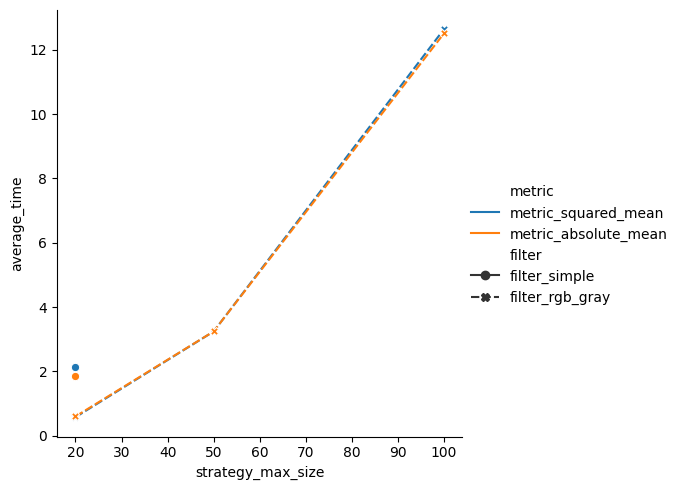

In [15]:
sns.relplot(
    data=df_performance,
    x='strategy_max_size',
    y='average_time',
    hue='metric',
    style='filter',
    markers=["o","X"],
    kind="line",
    )

# Full Grid Testing

In [10]:
from scipy.interpolate import NearestNDInterpolator

In [12]:
%matplotlib widget

In [ ]:

# def overlap_compare(
#         image_a_array:np.ndarray,
#         image_b_array:np.ndarray,
#         offset_ab:tuple|np.ndarray,
#         metric=lambda arr:np.min([(1/(np.std(arr)+1))**0.5,1])
#         )->float|tuple[float,np.ndarray]:
#     """Compares overlap of Image A and Image B using specified A-to-B relation and comparison metric.
#     - `image_a` and `image_b` are numpy arrays from PIL images converted to type `int`
#     - `offset_ab` is an (x,y) offset pair as generated by `MisFile.get_rels('r')`
#     - `metric` can be either a string referencing a built-in metric(`diff_abs_mean`,`diff_squared_mean`) or a function of the form `metric_function(difference_array)->float`
#     - Returns a float value representing the difference according to the metric
#     - `return_difference` changes output to (difference_value,difference_array)
#     """
#     ## Find overlap spans
#     try:
#         a_spans,b_spans=dga.overlap_spans(offset_ab,image_a_array.shape,image_b_array.shape)
#     except ValueError:
#         return float('nan')
#     ## Take difference of overlaps
#     overlap_a=image_a_array[a_spans[1][0]:a_spans[1][1],a_spans[0][0]:a_spans[0][1]]
#     overlap_b=image_b_array[b_spans[1][0]:b_spans[1][1],b_spans[0][0]:b_spans[0][1]]
#     ## Get difference metric
#     overlap_metric=metric(overlap_a)+metric(overlap_b)
#     ## Return of values
#     return overlap_metric

In [18]:
# optimized_relation
# np.argwhere(np.all(
#     a=[
#         full_dga_results["grid"][0]==optimized_relation[0],
#         full_dga_results["grid"][1]==optimized_relation[1]],
#     axis=0))[0]

In [ ]:
from misalign.model.relation import MISRelationRectangular

('image_a08.jpg', 'image_a09.jpg')
Initial Number: 20 Checking: 400 / 7,124,601
Quantile: 0.1/1.628 Number: 100 Checking: 975 / 729,712
Quantile: 0.01/1.442 Number: 200 Checking: 408 / 71,668
Quantile: 0.001/1.294 Number: 400 Checking: 156 / 7,083
Quantile: 0.0001/1.220 Number: 800 Checking: 708 / 708
Quantile: 0.05/1.583 Number: 200 Checking: 1574 / 354,546
Quantile: 0.005/1.403 Number: 400 Checking: 656 / 34,534
Quantile: 0.005/1.402 Number: 800 Checking: 3217 / 33,989
Quantile: 0.001/1.291 Number: 800 Checking: 5635 / 5,635
Optimized metric: 0.9150426095308153
Reference Optimized: (8, -938) Full Search DGA Optimized: (8, -938) Time: 105.4s


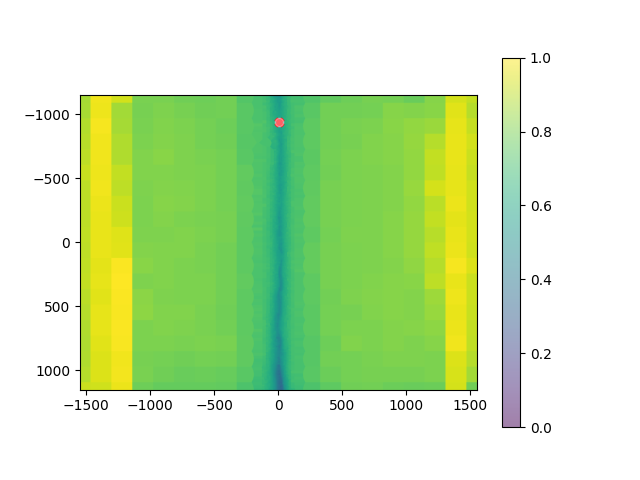

In [208]:
def strategy_full_search(
        image_a_array:np.ndarray,
        image_b_array:np.ndarray,
        metric,
        strategy_edge_avoid=20,
        **kwargs)->dict:
    x_min=-image_b_array.shape[1]+1+strategy_edge_avoid
    x_max=image_a_array.shape[1]-strategy_edge_avoid
    y_min=-image_b_array.shape[0]+1+strategy_edge_avoid
    y_max=+image_a_array.shape[0]-strategy_edge_avoid
    
    grid: np.ndarray=np.stack(
        arrays=np.meshgrid(
            np.arange(x_min,x_max),
            np.arange(y_min,y_max)
            )
        )
    grid_columns,grid_rows=np.meshgrid(
            np.arange(0,grid.shape[2]),
            np.arange(0,grid.shape[1]),
            )
    grid_results=np.full(grid.shape[1:],np.nan)

    def check_offset(iy,ix):
        grid_results[iy,ix]=dga.overlap_compare(
                    image_a_array=image_a_array,
                    image_b_array=image_b_array,
                    offset_ab=grid[:,iy,ix],
                    metric=metric)

    def run_interp():
        interp=NearestNDInterpolator(
            np.array([
                grid[0].flatten()[~np.isnan(grid_results.flatten())],
                grid[1].flatten()[~np.isnan(grid_results.flatten())]]).T,
            grid_results.flatten()[~np.isnan(grid_results.flatten())])
        interp_results=interp(grid[0].flatten(),grid[1].flatten()).reshape(grid_results.shape)
        return interp_results

    initial_number=20
    match_col=np.isin(element=grid_columns,
        test_elements=np.linspace(start=0,stop=grid.shape[2]-1,num=initial_number).astype(int))
    match_row=np.isin(element=grid_rows,
        test_elements=np.linspace(start=0,stop=grid.shape[1]-1,num=initial_number).astype(int))
    match_all=np.all([match_col,match_row],axis=0)
    print(f"Initial Number: {initial_number} Checking: {np.sum(match_all)} / {grid_results.size:,}")
    for iy,ix in zip(grid_rows[match_all].flatten(),grid_columns[match_all].flatten()):
        check_offset(iy,ix)
    interp_results=run_interp()

    def quantile_number_search(interp_results,quantile,number,full_count=1000):
        #TODO could add a maximum number here so if this is selecting i.e. 10,000 points it reduce to 1000.
        # quantile for threshold.
        quantile_cutoff=np.quantile(interp_results,quantile)
        # interpolation results within quantile threshold
        match_quantile=interp_results<=quantile_cutoff
        # offsets that have not been checked
        match_unchecked=np.isnan(grid_results)
        # offsets that have not been checked and are within quantile threshold
        match_remaining=np.all([match_quantile,match_unchecked],axis=0)
        # if the total remaining locations are less than the threshold for full search, then just check all of them.
        if np.sum(match_remaining)<=full_count:
            match_all=match_remaining
        # otherwise do grid reduction and search that reduced grid
        else:
            # offsets that match grid search columns
            match_col=np.isin(element=grid_columns,
                test_elements=np.linspace(start=0,stop=grid.shape[2]-1,num=number).astype(int))
            # offsets that match grid search rows
            match_row=np.isin(element=grid_rows,
                test_elements=np.linspace(start=0,stop=grid.shape[1]-1,num=number).astype(int))
            # offsets that match grid search positions
            match_all=np.all([match_col,match_row,match_remaining],axis=0)
        
        print(f"Quantile: {quantile}/{quantile_cutoff:0.3f} Number: {number} Checking: {np.sum(match_all)} / {np.sum(match_remaining):,}")
        for iy,ix in zip(grid_rows[match_all].flatten(),grid_columns[match_all].flatten()):
            check_offset(iy,ix)
        interp_results=run_interp()
        return interp_results
    
    interp_results=quantile_number_search(
        interp_results=interp_results,
        quantile=0.1,
        number=100,)
    interp_results=quantile_number_search(
        interp_results=interp_results,
        quantile=0.01,
        number=200,)  
    interp_results=quantile_number_search(
        interp_results=interp_results,
        quantile=0.001,
        number=400,)
    interp_results=quantile_number_search(
        interp_results=interp_results,
        quantile=0.0001,
        number=800,)

    metric_threshold=1
    # if minimum of metric is greater than the reasonable threshold. Expand preliminary search.
    if np.nanmin(grid_results)>=metric_threshold:
        interp_results=quantile_number_search(
            interp_results=interp_results,
            quantile=0.05,
            number=200,)  
        interp_results=quantile_number_search(
            interp_results=interp_results,
            quantile=0.005,
            number=400,)
        interp_results=quantile_number_search(
            interp_results=interp_results,
            quantile=0.005,
            number=800,
            full_count=5000,)
        if np.nanmin(grid_results)>=metric_threshold:
            interp_results=quantile_number_search(
                interp_results=interp_results,
                quantile=0.001,
                number=800,
                full_count=10000,)

    optimized_location=np.unravel_index(np.nanargmin(grid_results), grid_results.shape)
    # optimized_offset=tuple([int(value) for value in grid[:,grid_rows[optimized_location],grid_columns[optimized_location]]])
    optimized_offset=tuple(grid[:,optimized_location[0],optimized_location[1]].tolist())
        #tolist also does conversion into python integer

    print(f"Optimized metric: {np.nanmin(grid_results)}")

    # if "rectangular_relation" in kwargs:
    #     relation_index=np.argwhere(np.all(
    #         a=[grid[0]==optimized_relation[0],
    #             grid[1]==optimized_relation[1]],
    #         axis=0))[0]
    #     check_offset(relation_index[0],relation_index[1])
    # interp_results=run_interp()

    return {
        "grid":grid,
        "grid_results":grid_results,
        "interp_results":interp_results,
        "optimized_offset":optimized_offset,
        # "initial_offset":rectangular_relation
        }
def metric_adjusted_inverse_std(overlap_a:np.ndarray,overlap_b:np.ndarray)->float:
    def adjusted_inverse_std(overlap):
        return (1/(np.max((np.std(overlap)-20,1))))**0.5
    return (adjusted_inverse_std(overlap_a)+adjusted_inverse_std(overlap_b))/2

def metric_squared_normalized_mean(overlap_a:np.ndarray,overlap_b:np.ndarray)->float:
    return np.mean((overlap_a-overlap_b)**2)/(255**2)
def metric_abs_cubed_normalized_mean(overlap_a:np.ndarray,overlap_b:np.ndarray)->float:
    diff=(overlap_a-overlap_b).astype(np.int32)
    np.abs(diff,out=diff)
    return np.mean(diff**3)/(255**3)
def metric_norm_difference_max(overlap_a:np.ndarray,overlap_b:np.ndarray)->float:
    diff=(overlap_a-overlap_b).astype(np.int32)
    np.abs(diff,out=diff)
    return np.max(diff)/(255)

# def metric_combined(overlap_a:np.ndarray,overlap_b:np.ndarray):
#     return metric_squared_normalized_mean(overlap_a,overlap_b) +\
#         metric_adjusted_inverse_std(overlap_a,overlap_b)
def metric_combined(overlap_a:np.ndarray,overlap_b:np.ndarray):
    return np.sum([
        metric_norm_difference_max(overlap_a,overlap_b),
        metric_squared_normalized_mean(overlap_a,overlap_b)**0.1,
        metric_adjusted_inverse_std(overlap_a,overlap_b),
    ])

plt.close('all')
# full_relation=mis_project.get_relations()[3]
# for full_relation in mis_project.get_relations():
for full_relation in [mis_project.get_relations()[7]]:
    print(full_relation.get_reference())
    optimized_relation=dga.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            relation=full_relation,
            strategy=dga.strategy_scaled_grid,
            metric=dga.metric_squared_mean,
            strategy_max_size=20,
            strategy_grid_scale=1,
            filter=dga.filter_rgb_gray
            )["optimized_offset"]
    start_time=timeit.default_timer()
    full_dga_results=dga.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            # relation=full_relation,
            relation=MISRelationRectangular(image_pair=full_relation.get_reference(),rectangular=optimized_relation), #optimized relation
            strategy=strategy_full_search,
            metric=metric_combined,
            filter=dga.filter_rgb_gray,
            strategy_edge_avoid=50,
            )
    end_time=timeit.default_timer()
    print(f"Reference Optimized: {optimized_relation} Full Search DGA Optimized: {full_dga_results["optimized_offset"]} Time: {end_time-start_time:0.1f}s")
    plt.figure()
    plt.imshow(
        X=full_dga_results["interp_results"],
        norm=colors.LogNorm(vmin=np.nanmin(full_dga_results["interp_results"]),
                            vmax=np.nanmax(full_dga_results["interp_results"])),
        extent=(np.min(full_dga_results["grid"][0])-0.5,
                np.max(full_dga_results["grid"][0])+0.5,
                np.max(full_dga_results["grid"][1])+0.5,
                np.min(full_dga_results["grid"][1])-0.5,) #xmin,xmax,ymin,ymax)
        )
    plt.scatter(*optimized_relation,marker="X",c='r')
    plt.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink',alpha=0.5)
    plt.colorbar()
    plt.show()

In [81]:
# Get the metric values and number of offsets in the interpolation below a certain value.
print(np.unique(full_dga_results["interp_results"][full_dga_results["interp_results"]<1.1],return_counts=True))
# Get the number of offsets in the interpolation below a certain quantile
for quantile in [0.1,0.05,0.01,0.005,0.001,0.0005,0.0001,0]:
    quantile_cutoff=np.quantile(a=full_dga_results["interp_results"],q=quantile)
    quantile_total=np.sum(full_dga_results["interp_results"]<quantile_cutoff)
    print(f"Quantile: {quantile} - Cutoff: {quantile_cutoff:.4f} - Total {quantile_total:,}")

(array([1.05079741, 1.08167213, 1.0953599 , 1.09566617, 1.09767941,
       1.09814792]), array([10,  5,  2,  6,  7,  5]))
Quantile: 0.1 - Cutoff: 1.6623 - Total 766,629
Quantile: 0.05 - Cutoff: 1.6181 - Total 383,525
Quantile: 0.01 - Cutoff: 1.4750 - Total 76,289
Quantile: 0.005 - Cutoff: 1.4352 - Total 38,297
Quantile: 0.001 - Cutoff: 1.3358 - Total 7,628
Quantile: 0.0005 - Cutoff: 1.3098 - Total 3,804
Quantile: 0.0001 - Cutoff: 1.2737 - Total 759
Quantile: 0 - Cutoff: 1.0508 - Total 0


In [ ]:
metric,difference=dga.overlap_compare(
        image_a_array=dga.filter_rgb_gray(mis_project.get_image(full_relation.get_reference()[0])),
        image_b_array=dga.filter_rgb_gray(mis_project.get_image(full_relation.get_reference()[1])),
        offset_ab=(-81,250),
        metric=lambda a,b:0,
        return_difference=True
        )  # ty:ignore[not-iterable]
plt.imshow(difference)

np.int16(69)

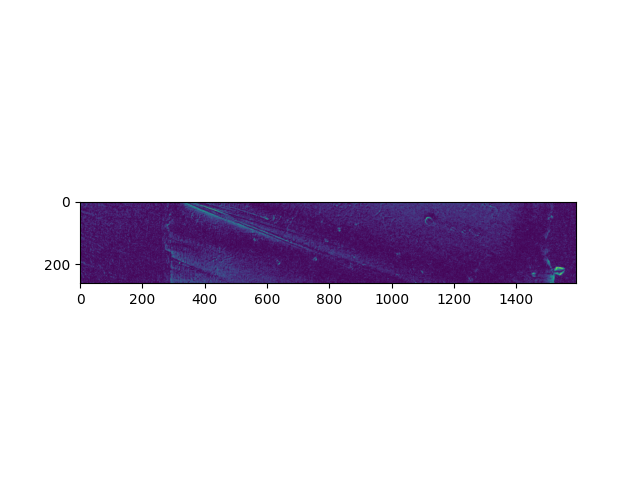

In [213]:
full_relation=mis_project.get_relations()[7]
metric,difference=dga.overlap_compare(
        image_a_array=dga.filter_rgb_gray(mis_project.get_image(full_relation.get_reference()[0])),
        image_b_array=dga.filter_rgb_gray(mis_project.get_image(full_relation.get_reference()[1])),
        offset_ab=(8, -938),#optimized_relation,#(-82, 1128),#(8, -938)
        metric=lambda a,b:0,
        return_difference=True
        )  # ty:ignore[not-iterable]
plt.figure()
plt.imshow(np.abs(difference))
np.max(np.abs(difference))

Initial: (9, -939) Optimized: (8, -938)


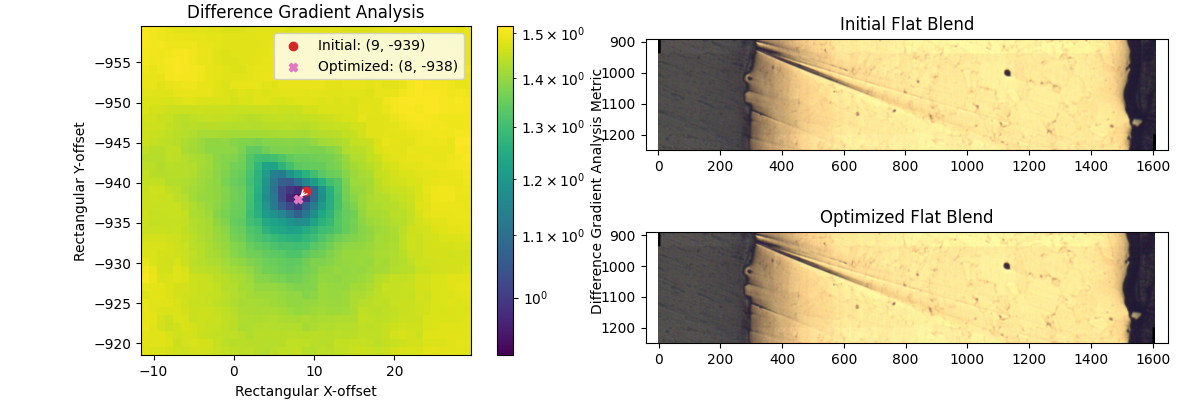

In [197]:
def metric_combined(overlap_a:np.ndarray,overlap_b:np.ndarray):
    return np.sum([
        metric_norm_difference_max(overlap_a,overlap_b),
        metric_squared_normalized_mean(overlap_a,overlap_b)**0.1,
        metric_adjusted_inverse_std(overlap_a,overlap_b),
    ])

selected_relation=mis_project.get_relations()[7]
selected_dga_results=dga.difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        relation=selected_relation,
        strategy=dga.strategy_scaled_grid,
        metric=metric_combined,
        strategy_max_size=20,
        strategy_grid_scale=1,
        filter=dga.filter_rgb_gray
        )
print("Initial:",selected_dga_results["initial_offset"],"Optimized:",selected_dga_results["optimized_offset"])
dga.plot_grid_difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        dga_grid_result=selected_dga_results,
    )
plt.show()

In [139]:
for iy in np.linspace(start=0,stop=full_dga_results["grid"].shape[1]-1,num=50).astype(int):
    for ix in np.linspace(start=0,stop=full_dga_results["grid"].shape[2]-1,num=50).astype(int):
        print(iy,ix)

0 0
0 65
0 130
0 195
0 261
0 326
0 391
0 456
0 522
0 587
0 652
0 717
0 783
0 848
0 913
0 978
0 1044
0 1109
0 1174
0 1240
0 1305
0 1370
0 1435
0 1501
0 1566
0 1631
0 1696
0 1762
0 1827
0 1892
0 1957
0 2023
0 2088
0 2153
0 2219
0 2284
0 2349
0 2414
0 2480
0 2545
0 2610
0 2675
0 2741
0 2806
0 2871
0 2936
0 3002
0 3067
0 3132
0 3198
48 0
48 65
48 130
48 195
48 261
48 326
48 391
48 456
48 522
48 587
48 652
48 717
48 783
48 848
48 913
48 978
48 1044
48 1109
48 1174
48 1240
48 1305
48 1370
48 1435
48 1501
48 1566
48 1631
48 1696
48 1762
48 1827
48 1892
48 1957
48 2023
48 2088
48 2153
48 2219
48 2284
48 2349
48 2414
48 2480
48 2545
48 2610
48 2675
48 2741
48 2806
48 2871
48 2936
48 3002
48 3067
48 3132
48 3198
97 0
97 65
97 130
97 195
97 261
97 326
97 391
97 456
97 522
97 587
97 652
97 717
97 783
97 848
97 913
97 978
97 1044
97 1109
97 1174
97 1240
97 1305
97 1370
97 1435
97 1501
97 1566
97 1631
97 1696
97 1762
97 1827
97 1892
97 1957
97 2023
97 2088
97 2153
97 2219
97 2284
97 2349
97 2414
97 

array([[   0,    0,    0, ...,    0,    0,    0],
       [   1,    1,    1, ...,    1,    1,    1],
       [   2,    2,    2, ...,    2,    2,    2],
       ...,
       [2396, 2396, 2396, ..., 2396, 2396, 2396],
       [2397, 2397, 2397, ..., 2397, 2397, 2397],
       [2398, 2398, 2398, ..., 2398, 2398, 2398]], shape=(2399, 3199))

In [136]:
grid_columns,grid_rows=np.meshgrid(
            np.arange(0,full_dga_results["grid"].shape[2]),
            np.arange(0,full_dga_results["grid"].shape[1]),
            )
grid_rows

is_col=np.isin(
    element=grid_columns,
    test_elements=np.linspace(start=0,stop=full_dga_results["grid"].shape[2]-1,num=5).astype(int))
is_row=np.isin(
    element=grid_rows,
    test_elements=np.linspace(start=0,stop=full_dga_results["grid"].shape[1]-1,num=5).astype(int))
is_match=np.all([is_row,is_col],axis=0)

for iy,ix in zip(grid_columns[is_match].flatten(),grid_rows[is_match].flatten()):
    print(iy,ix)
# plt.close('all')
# plt.figure()
# plt.imshow(is_match)
# plt.show()

0 0
799 0
1599 0
2398 0
3198 0
0 599
799 599
1599 599
2398 599
3198 599
0 1199
799 1199
1599 1199
2398 1199
3198 1199
0 1798
799 1798
1599 1798
2398 1798
3198 1798
0 2398
799 2398
1599 2398
2398 2398
3198 2398
